# EDA for PGA using the mmi_pga_t1.csv

## Constants

In [88]:
from enum import Enum
FILE_LOCATION = "data/processed/mmi_pga_t1.csv"
MODEL_SAVE_LOCATION = "models/radius"

In [3]:

# Lookup table to convert Modified Mercalli Intensity (MMI) to Peak Ground Acceleration (PGA) in units of g.
# Values represent median PGA for each MMI value, sourced from the USGS dataset.
# NOTE: This lookup table and helper function are for utility/reference only and are NOT 
# used during model training or testing.
pga_look_up = {
	2.0: 0.002268553,
	2.5: 0.00312874,
	3.0: 0.0055180005,
	3.5: 0.010397652,
	4.0: 0.018992,
	4.5: 0.027748,
	5.0: 0.034651877,
	5.5: 0.058811,
	6.0: 0.069783,
	6.5: 0.10616,
	7.0: 0.13697,
	7.5: 0.20955,
	8.0: 0.27436,
}


def get_pga_value(mmi):
	"""Returns the median PGA value (in g) corresponding to a given MMI level.

	Note:
		This conversion function is strictly a reference utility and is not used
		within the training or evaluation/test pipelines.
	"""
	if mmi in pga_look_up:
		return pga_look_up[mmi]
	else:
		raise ValueError(f"MMI value {mmi} not found in lookup table.")

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

df = pd.read_csv(FILE_LOCATION)

## Basic Data Exploration

In [5]:
df.shape

(301396, 10)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301396 entries, 0 to 301395
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   usgs_id        301396 non-null  str    
 1   longitude      301396 non-null  float64
 2   latitude       301396 non-null  float64
 3   magnitude      301396 non-null  float64
 4   mmi            301396 non-null  float64
 5   pga            301396 non-null  float64
 6   regime         301396 non-null  str    
 7   r_hypo         301396 non-null  float64
 8   vs30           301396 non-null  float64
 9   depth_surface  301396 non-null  float64
dtypes: float64(8), str(2)
memory usage: 23.0 MB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,301396.0,-118.929710,2.261011,-1.251338e+02,-121.244300,-118.080000,-117.304200,-112.0577
latitude,301396.0,35.676525,2.115403,3.228617e+01,33.948500,34.813330,37.481170,48.5865
magnitude,301396.0,4.948994,0.957927,3.050000e+00,4.230000,4.620000,5.440000,7.3000
mmi,301396.0,3.050380,1.051352,1.000000e+00,2.200000,3.000000,3.600000,9.1000
pga,301396.0,0.016917,0.044082,5.430000e-07,0.002017,0.005421,0.014363,1.6440
r_hypo,301396.0,103.816540,92.228590,7.542038e-01,38.449632,76.094390,143.794875,1451.8240
vs30,301396.0,398.378041,145.863945,1.385875e+02,293.500100,352.110300,454.997900,1049.8210
depth_surface,301396.0,10.985359,4.564381,0.000000e+00,8.408000,10.709000,14.065000,52.4200


In [8]:
df.head()

,usgs_id,longitude,latitude,magnitude,mmi,pga,regime,r_hypo,vs30,depth_surface
0,nc71729135,-122.7432,38.79267,4.16,5.8,0.039036,active,2.129752,710.1000,1.522
1,nc72737985,-122.8413,38.82217,5.01,5.8,0.001188,active,2.670254,733.4000,2.086
2,ci3031111,-116.4370,34.20000,7.30,7.9,0.274360,active,10.555350,399.1442,0.957
3,nc72737985,-122.8413,38.82217,5.01,6.1,0.001188,active,2.307831,733.4000,2.086
4,nc21543835,-122.7873,38.86667,4.56,6.1,0.003430,active,2.979217,423.9376,3.227


## Histogram of Datas.

In [69]:
class Features(str, Enum):
	DEPTH = "depth_surface"
	MAGNITUDE = "magnitude"
	PGA = "pga"
	RHYPO = "r_hypo"
	REGIME = "regime"
	VS30 = "vs30"

# only for plotting and analysis, not used in training or testing
ALL_NUMERIC_FEATURES = [Features.DEPTH, Features.MAGNITUDE,Features.RHYPO]
ALL_FEATURES = ALL_NUMERIC_FEATURES + [Features.REGIME]
TARGET_FEATURE = Features.PGA

ALL_NUMERIC_PROPERTIES = ALL_NUMERIC_FEATURES + [TARGET_FEATURE]
ALL_PROPERTIES = ALL_FEATURES + [TARGET_FEATURE]

class MetaData(str, Enum):
	ID = "usgs_id"
	LATITUDE = "latitude"
	LONGITUDE = "longitude"
	MMI = "mmi"

def calculate_plot_dimension(count:int)-> tuple[int, int]:
	horizontal = int(np.ceil(np.sqrt(count)))
	vertical = int(np.ceil(count / horizontal))
	if horizontal * vertical < count:
		vertical += 1
	if horizontal < vertical:
		horizontal, vertical = vertical, horizontal
	return (horizontal, vertical)



In [10]:
df_log = df.copy()
df_log["log_pga"] = np.log(df_log[Features.PGA])

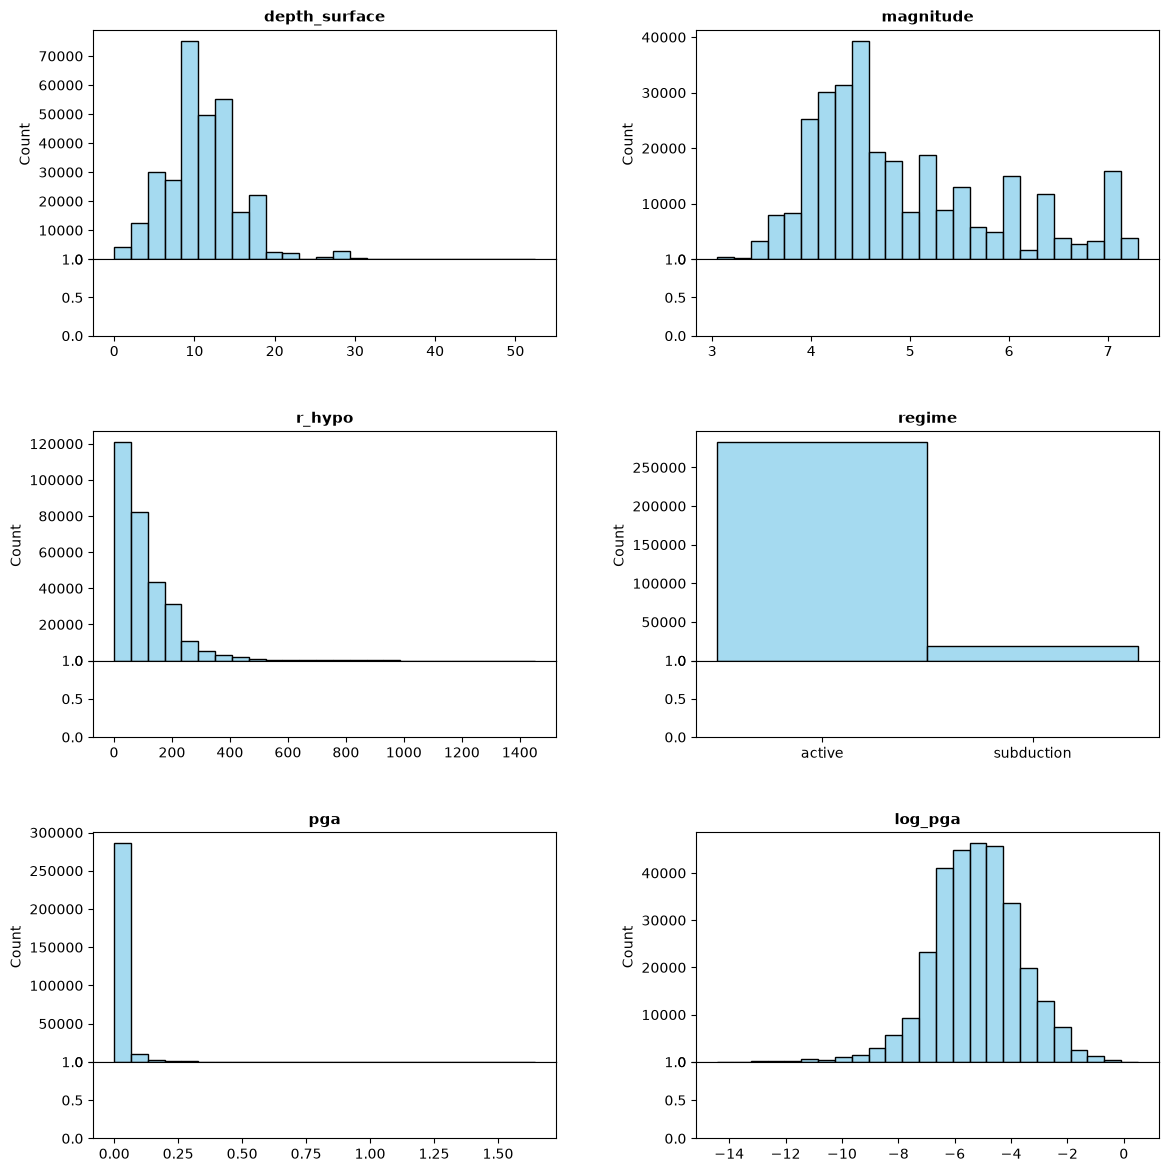

0

In [11]:
fig = plt.figure(figsize=(12, 12))
used_properties = ALL_PROPERTIES + ["log_pga"]
h,v = calculate_plot_dimension(len(used_properties))

subfigs = fig.subfigures(h, v, wspace=0.01, hspace=0.01).flatten()

for i, col in enumerate(used_properties):
	s_fig = subfigs[i]
	ax1, ax2 = s_fig.subplots(
		2, 1, 
		sharex=True, 
		gridspec_kw={"height_ratios": [3, 1]}
	)
	sns.histplot(
		data=df_log, 
		x=col, 
		bins=25, 
		color="skyblue",                         
		ax=ax1
	)
	col_name = col.value if isinstance(col, Enum) else col
	ax1.set_title(f"{col_name}", fontsize=11, fontweight="bold")
	ax1.set_xlabel("")
	s_fig.subplots_adjust(hspace=0)

plt.show()

del fig, subfigs, ax1, ax2, h, v, i, col,used_properties
gc.collect()

## Box Plots

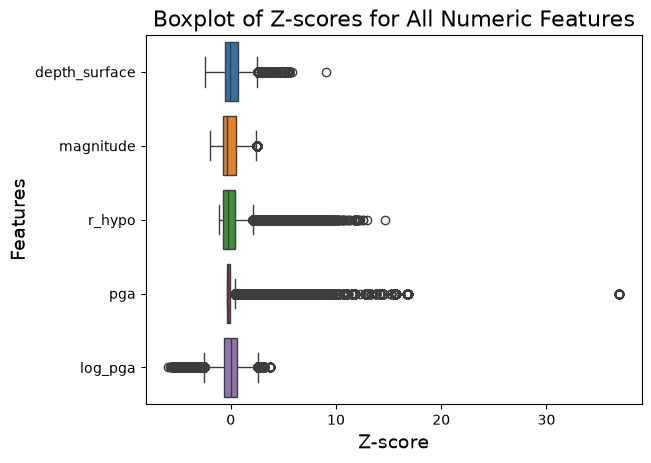

339

In [12]:

used_properties = ALL_NUMERIC_PROPERTIES + ["log_pga"]
numeric_df = df_log[used_properties].select_dtypes(include="number")
z = (numeric_df - numeric_df.mean()) / numeric_df.std()
sns.boxplot(
	data=z,
	orient="h",
)
plt.title("Boxplot of Z-scores for All Numeric Features", fontsize=16)
plt.xlabel("Z-score", fontsize=14)
plt.ylabel("Features", fontsize=14)
plt.show()

del numeric_df, z,used_properties
gc.collect()

## Heatmap of Correlation Matrix for All Numeric Features

4237

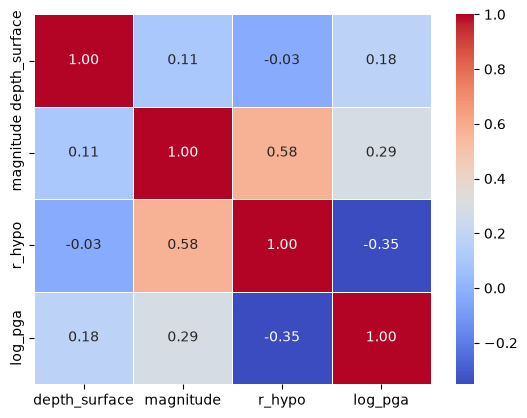

In [13]:
used_properties = ALL_NUMERIC_PROPERTIES + ["log_pga"]
sns.heatmap(
	data= df_log[used_properties].drop(columns=[Features.PGA]).corr(),
	annot=True,
	fmt=".2f",
	cmap="coolwarm",
	linewidths=0.5,
)
del used_properties
gc.collect()

This will take a while to run, please be patient...


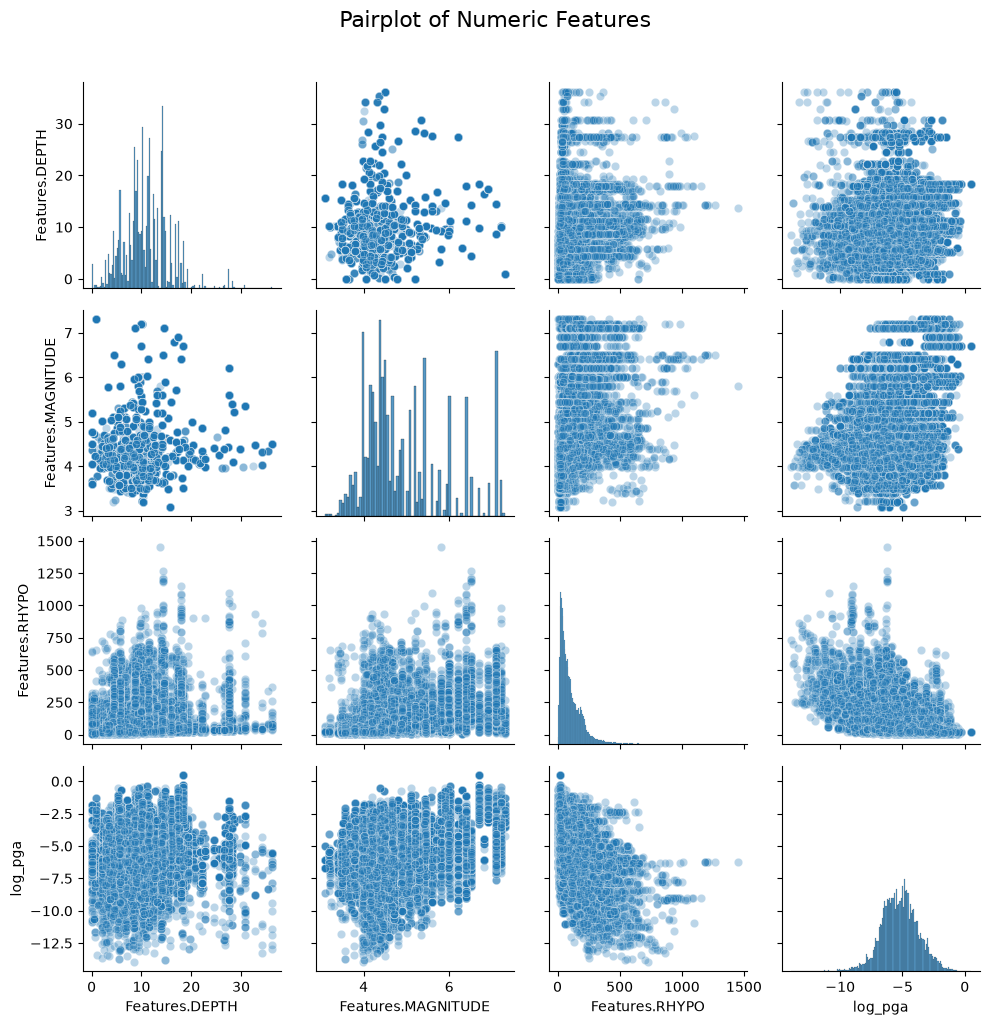

301

In [14]:
print("This will take a while to run, please be patient...")
used_properties = [Features.DEPTH, Features.MAGNITUDE, Features.RHYPO, "log_pga"]
sub_df = df_log[used_properties].sample(frac=0.25, random_state=42)

sns.pairplot(
	data=sub_df,
	vars=used_properties,
	plot_kws={'alpha': 0.3}
)
plt.suptitle("Pairplot of Numeric Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

del sub_df,used_properties
gc.collect()

## Model Training and Evaluation

In [89]:
from sklearn.linear_model import (
	LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge, HuberRegressor
)
from sklearn.neural_network import MLPRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor


def create_models() -> dict:
	"""Creates a dictionary of regression models with heavily regularized tree models."""
	return {
		"LinearRegression": LinearRegression(),
		"HuberRegressor": HuberRegressor(max_iter=1000, alpha=0.001, epsilon=1.4),
		# "MLPRegressor_NN": MLPRegressor(
		# 	hidden_layer_sizes=(16, 32),
		# 	activation="relu",
		# 	solver="adam",
		# 	alpha=0.002,
		# 	batch_size=512,
		# 	learning_rate_init=0.002,
		# 	max_iter=200,
		# 	early_stopping=True,
		# 	n_iter_no_change=15,
		# 	random_state=42
		# ),
		"LightGBM_Regularized": LGBMRegressor(
			n_estimators=150,
			learning_rate=0.03,
			num_leaves=12,           # Reduced from 31 to prevent micro-splitting 4D space
			max_depth=4,             # Shallow depth forces global physics trends
			min_child_samples=200,   # Demands 200+ seismic records per leaf
			reg_lambda=10.0,         # Strong L2 regularization
			subsample=0.7,
			colsample_bytree=0.8,
			random_state=42,
			n_jobs=-1,
			verbosity=-1
		),
		"XGBoost_Regularized": XGBRegressor(
			n_estimators=150,
			learning_rate=0.03,
			max_depth=4,             # Shallow depth prevents spatial memorization
			min_child_weight=200,    # Requires large sample weight per leaf
			reg_lambda=10.0,         # Strong L2 regularization
			subsample=0.7,
			colsample_bytree=0.8,
			random_state=42,
			n_jobs=-1
		)
	}



In [16]:
def create_unique_splits(df: pd.DataFrame, id_col: str, frac: float = 0.75, random_state: int = 42):
	unique_ids = df[id_col].unique()
	sampled_ids = pd.Series(unique_ids).sample(frac=frac, random_state=random_state)
	return df[df[id_col].isin(sampled_ids)].copy()

In [82]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


class RegressorEvaluator:
	"""
	The RegressorEvaluator class provides a structured and reusable pipeline for evaluating multiple 
	regression models on a dataset. It manages the entire workflow, including data preparation, 
	feature filtering, model training, evaluation, and prediction generation.

	Only the features specified in `X_features` and the target in `y_feature` are retained for training 
	and testing. All unselected features are dropped from the pipeline.
	"""

	def __init__(self, df, X_features, y_feature, split_id_col, models, 
				 test_size=0.05, random_state=42, show_full_df=False, un_log_mae_mse=False):
		"""
		Initializes the evaluation pipeline.

		Args:
			df (pd.DataFrame): The input DataFrame.
			X_features (list): List of feature column names to be used as model inputs (X).
			y_feature (str): Name of the target variable column (y).
			split_id_col (str): Column to group by for GroupShuffleSplit.
			models (dict): Dictionary of instantiated sklearn models (e.g., {'Linear': LinearRegression()}).
			test_size (float): Proportion of groups to include in the test split.
			random_state (int): Seed for reproducibility.
			show_full_df (bool): If True, retains all X_features in the prediction output DataFrame.
		"""
		self.df = df.copy()
		self.X_features = X_features
		self.y_feature = y_feature
		self.split_id_col = split_id_col
		self.models = models
		self.test_size = test_size
		self.random_state = random_state
		self.show_full_df = show_full_df
		self.un_log_mae_mse = un_log_mae_mse
		# Validate feature existence
		missing_cols = [col for col in self.X_features + [self.y_feature, self.split_id_col] if col not in self.df.columns]
		if missing_cols:
			raise KeyError(f"The following required columns are missing from the input DataFrame: {missing_cols}")

		# Placeholders for state
		self.train_df, self.test_df = None, None
		self.X_train, self.X_test = None, None
		self.y_train, self.y_test = None, None
		self.eval_df = None
		self.predictions_df = None

	def prepare_data(self):
		"""
		Filters out non-selected features, performs GroupShuffleSplit, and prepares X/y datasets.

		Returns:
			X_train, X_test, y_train, y_test: Prepared training and testing datasets.
		"""
		# 1. Drop all columns except X_features, y_feature, and split_id_col
		keep_cols = list(dict.fromkeys(self.X_features + [self.y_feature, self.split_id_col]))
		self.df = self.df[keep_cols]

		# 2. Group Shuffle Split using split_id_col
		gss = GroupShuffleSplit(n_splits=1, test_size=self.test_size, random_state=self.random_state)
		train_idx, test_idx = next(gss.split(self.df, groups=self.df[self.split_id_col]))

		self.train_df = self.df.iloc[train_idx].copy()
		self.test_df = self.df.iloc[test_idx].copy()

		# 3. Separate Features (X) and Target (y) using explicit feature lists
		self.X_train = self.train_df[self.X_features].copy()
		self.y_train = self.train_df[self.y_feature].copy()
		self.X_test = self.test_df[self.X_features].copy()
		self.y_test = self.test_df[self.y_feature].copy()

		# 4. Remove split_id_col from train_df and test_df if present
		if self.split_id_col in self.train_df.columns:
			self.train_df = self.train_df.drop(columns=[self.split_id_col])
			self.test_df = self.test_df.drop(columns=[self.split_id_col])

		print(f"Train set shape: X={self.X_train.shape}, y={self.y_train.shape}")
		print(f"Test set shape:  X={self.X_test.shape}, y={self.y_test.shape}")
		print(f"X_test columns:  {self.X_test.columns.tolist()}")
		print(f"y_test column:   {self.y_test.name}")

		return self.X_train, self.X_test, self.y_train, self.y_test

	def fit_and_evaluate(self):
		"""Trains models, prints coefficients, and calculates metrics."""
		eval_records = []

		for model_name, model in self.models.items():
			# Train model
			model.fit(self.X_train, self.y_train)

			# Inspect coefficients / intercept
			coef_str = f"{model_name} Coefficients: "
			if hasattr(model, 'coef_'):
				coef_str += str(model.coef_)
			else:
				coef_str += "N/A"
			if hasattr(model, 'intercept_'):
				coef_str += f", Intercept: {model.intercept_}"
			print(coef_str)

			# Evaluate
			pred = model.predict(self.X_test)
			train_score = model.score(self.X_train, self.y_train)
			test_score = model.score(self.X_test, self.y_test)
			
			eval_records.append({
				"model": model_name,
				"train_score": train_score,
				"test_score": test_score,
				"r2_score": r2_score(self.y_test, pred) if not self.un_log_mae_mse else r2_score(self.y_test,pred),
				"mse": mean_squared_error(self.y_test, pred) if not self.un_log_mae_mse else mean_squared_error(10**self.y_test, 10**pred),
				"mae": mean_absolute_error(self.y_test, pred) if not self.un_log_mae_mse else mean_absolute_error(10**self.y_test, 10**pred),
			})

		self.eval_df = pd.DataFrame(eval_records)
		return self.eval_df

	def generate_predictions(self):
		"""Appends model predictions to the test dataframe."""
		if self.test_df is None or self.X_test is None:
			raise ValueError("Data not prepared. Call prepare_data() before generating predictions.")

		if self.show_full_df:
			self.predictions_df = self.test_df.copy()
		else:
			self.predictions_df = self.test_df[[self.y_feature]].copy()
		
		for model_name, model in self.models.items():
			self.predictions_df[f"{model_name}_pred"] = model.predict(self.X_test)

		return self.predictions_df

	def run(self):
		"""Executes the entire pipeline and returns evaluation and prediction DataFrames."""
		self.prepare_data()
		print("-" * 50)
		self.fit_and_evaluate()
		self.generate_predictions()
		
		return self.eval_df, self.predictions_df

In [93]:
# formula: M~ a + b*Mag + c*MMi + d*log(MMI+1) + e*log(Depth+1) + f*log(Vs30/760)
import joblib

print("Grab a cup of coffee, this will take a while to run...\n"
	  "Estimated 2-3 minutes for the entire pipeline to complete.")

print("Data Set Size:", df.size)
epsilon = 1e-8

id_col = MetaData.ID.value
df_sample = create_unique_splits(df, id_col=id_col, frac=1.0, random_state=42)

active_df = df_sample[df_sample[Features.REGIME.value] == "active"].copy()

active_df["log_depth"] = np.log10(active_df[Features.DEPTH.value]+epsilon)
active_df["log_pga"] = np.log10(active_df[Features.PGA.value] + epsilon)
active_df["log_rhypo"] = np.log10(active_df[Features.RHYPO.value] + epsilon)
active_df["log_vs_30"] = np.log10((active_df[Features.VS30.value] + epsilon )/ 760)
# active_df["log_pga_by_mag"] = active_df["log_pga"] * active_df[Features.MAGNITUDE.value]
# active_df["log_depth_by_mag"] = active_df["log_depth"] * active_df[Features.MAGNITUDE.value]
# active_df["log_pga_by_log_vs30"] = active_df["log_pga"] * active_df["log_vs_30"]

y_feature = "log_rhypo"	
X_features = ['magnitude', 
              'log_pga', 
			  'log_depth',
              'log_vs_30',
            #   "log_pga_by_mag",
			#   "log_depth_by_mag",
			#   "log_pga_by_log_vs30",
			  ]

models = create_models()
evaluator = RegressorEvaluator(
	df=active_df,
	X_features=X_features,
	y_feature=y_feature,
	split_id_col=id_col,
	models=models,
	test_size=0.2,
	random_state=2,
	un_log_mae_mse=True
)

evaluation_metrics, test_predictions = evaluator.run()

print(evaluation_metrics)

for col in test_predictions.columns:
	if col.startswith("log_") or col.endswith("_pred"):
		test_predictions[col] = 10 ** test_predictions[col]
display(test_predictions)




model = evaluator.models["LinearRegression"]
joblib.dump(model, MODEL_SAVE_LOCATION + "/linear_regression_model.pkl")


del evaluator, active_df, df_sample, models, X_features, y_feature, id_col
gc.collect()

Grab a cup of coffee, this will take a while to run...
Estimated 2-3 minutes for the entire pipeline to complete.
Data Set Size: 3013960
Train set shape: X=(228423, 4), y=(228423,)
Test set shape:  X=(54474, 4), y=(54474,)
X_test columns:  ['magnitude', 'log_pga', 'log_depth', 'log_vs_30']
y_test column:   log_rhypo
--------------------------------------------------
LinearRegression Coefficients: [ 0.30093863 -0.3513688   0.08176614 -0.02474541], Intercept: -0.4936629515789499
HuberRegressor Coefficients: [ 0.30143142 -0.36359088  0.12333226 -0.02889194], Intercept: -0.5544903267462381
LightGBM_Regularized Coefficients: N/A
XGBoost_Regularized Coefficients: N/A, Intercept: [1.8748417]
                  model  train_score  test_score  r2_score          mse  \
0      LinearRegression     0.683111    0.701057  0.701057  2327.818940   
1        HuberRegressor     0.680483    0.689218  0.689218  2528.735061   
2  LightGBM_Regularized     0.784481    0.668749  0.668749  3298.070302   
3   XG

,log_rhypo,LinearRegression_pred,HuberRegressor_pred,LightGBM_Regularized_pred,XGBoost_Regularized_pred
44,5.780171,24.399540,23.893750,20.293387,20.962086
46,5.361514,20.741130,20.215888,17.398655,19.007420
49,5.625977,24.652846,24.183622,20.253158,21.315945
52,6.097360,24.400204,23.894510,20.293387,20.962086
55,6.189357,24.652846,24.183622,20.253158,21.315945
...,...,...,...,...,...
301229,6.065004,15.846366,15.224374,10.924974,10.352126
301230,3.818212,29.933283,28.724549,27.155474,23.023144
301282,9.118602,45.760554,45.827184,54.542960,52.292591
301316,8.489397,30.018270,30.333549,28.563859,27.115063


2884

In [80]:
# formula: M~ a + b*Mag + c*MMi + d*log(MMI+1) + e*log(Depth+1) + f*log(Vs30/760)

print("Grab a cup of coffee, this will take a while to run...\n"
	  "Estimated 2-3 minutes for the entire pipeline to complete.")

print("Data Set Size:", len(df))
epsilon = 1e-8

id_col = MetaData.ID.value
df_sample = create_unique_splits(df, id_col=id_col, frac=1.0, random_state=100)

active_df = df_sample[df_sample[Features.REGIME.value] == "active"].copy()

active_df["log_pga"] = np.log10(active_df[Features.PGA.value] + epsilon)

active_df["log_depth"] = np.log10(active_df[Features.DEPTH.value]+epsilon)
active_df["log_rhypo"] = np.log10(active_df[Features.RHYPO.value] + epsilon)
active_df["log_vs_30"] = np.log10((active_df[Features.VS30.value] + epsilon )/ 760)


y_feature = "log_pga"	
X_features = ['magnitude', 'log_rhypo',
              'log_vs_30', Features.RHYPO.value, "log_depth",
			  ]

models = create_models()
evaluator = RegressorEvaluator(
	df=active_df,
	X_features=X_features,
	y_feature=y_feature,
	split_id_col=id_col,
	models=models,
	test_size=0.2,
	random_state=2,
	un_log_mae_mse=True
)

evaluation_metrics, test_predictions = evaluator.run()

print(evaluation_metrics)

# for col in test_predictions.columns:
# 	if col.startswith("log_") or col.endswith("_pred"):
# 		test_predictions[col] = 10 ** test_predictions[col]
display(test_predictions)

del evaluator, active_df, df_sample, models, X_features, y_feature, id_col
gc.collect()

Grab a cup of coffee, this will take a while to run...
Estimated 2-3 minutes for the entire pipeline to complete.
Data Set Size: 301396
Train set shape: X=(228423, 5), y=(228423,)
Test set shape:  X=(54474, 5), y=(54474,)
X_test columns:  ['magnitude', 'log_rhypo', 'log_vs_30', 'r_hypo', 'log_depth']
y_test column:   log_pga
--------------------------------------------------
LinearRegression Coefficients: [ 0.55477817 -1.08833114 -0.07641109 -0.00198891  0.23899044], Intercept: -3.0025534855480718
HuberRegressor Coefficients: [ 0.55139046 -1.09969375 -0.11968896 -0.0021013   0.48559977], Intercept: -3.200262074996978
LightGBM_Regularized Coefficients: N/A
XGBoost_Regularized Coefficients: N/A, Intercept: [-2.242499]
                  model  train_score  test_score  r2_score         mse  \
0      LinearRegression     0.585310    0.581049  0.581049  562.699323   
1        HuberRegressor     0.566267    0.568413  0.568413  562.723809   
2  LightGBM_Regularized     0.706191    0.577745  0.

,log_pga,LinearRegression_pred,HuberRegressor_pred,LightGBM_Regularized_pred,XGBoost_Regularized_pred
44,-1.586918,-1.339296,-1.381010,-1.582082,-1.599286
46,-1.377309,-1.293351,-1.329224,-1.556761,-1.560147
49,-1.586918,-1.312359,-1.346078,-1.556761,-1.560147
52,-1.586918,-1.365141,-1.407134,-1.582082,-1.599286
55,-1.586918,-1.358588,-1.392841,-1.556761,-1.560147
...,...,...,...,...,...
301229,-0.898924,-1.250415,-1.282452,-1.751487,-1.756744
301230,-2.113330,-1.345169,-1.470444,-2.004522,-2.006487
301282,-1.573826,-1.028983,-1.019759,-1.348968,-1.220534
301316,-1.970824,-1.585243,-1.570758,-1.785895,-1.707091


873

## HyperParameter Tuning for Neutal Network (MLPRegressor)

In [19]:
def  create_ml_model(
		hidden_layer_sizes=(64, 32), 
		activation="relu", 
		solver="adam", alpha=0.001, 
		batch_size=256, 
		learning_rate_init=0.001, 
		max_iter=100, 
		early_stopping=True, 
		n_iter_no_change=10, 
		random_state=42):
	return MLPRegressor(
			hidden_layer_sizes=hidden_layer_sizes,
			activation=activation,
			solver=solver,
			alpha=alpha,
			batch_size=batch_size,
			learning_rate_init=learning_rate_init,
			max_iter=max_iter,
			early_stopping=early_stopping,
			n_iter_no_change=n_iter_no_change,
			random_state=random_state
		)

In [20]:
def feature_engineering(
		df: pd.DataFrame,id_col: str,sample_size: 
		float,random_state: int = 42,epsilon: float = 1e-8
	) ->tuple[pd.DataFrame, list[str], str]:
	
	df_sample = create_unique_splits(df, id_col=id_col, frac=sample_size, random_state=random_state)

	active_df = df_sample[df_sample[Features.REGIME.value] == "active"].copy()

	active_df["log_depth"] = np.log10(active_df[Features.DEPTH.value] + epsilon)
	active_df["log_pga"] = np.log10(active_df[Features.PGA.value] + epsilon)
	active_df["log_rhypo"] = np.log10(active_df[Features.RHYPO.value] + epsilon)
	active_df["vs_30"] = np.log10((active_df["vs30"] + epsilon )/ 760)
	
	return active_df, ['magnitude', 'log_pga', 'log_depth', 'vs_30'] , "log_rhypo"


In [21]:
from dataclasses import dataclass, field

from sklearn.model_selection import (
	GroupShuffleSplit,
	RandomizedSearchCV,
	PredefinedSplit,
)

from sklearn.metrics import (
	r2_score,
	mean_squared_error,
	mean_absolute_error,
)


@dataclass
class MLPConfig:
	# =========================================================
	# Dataset / split configuration
	# =========================================================

	sample_size: float = 1.0
	test_size: float = 0.20
	val_size: float = 0.10
	random_state: int = 42

	# =========================================================
	# MLP training configuration
	# =========================================================

	model_iteration: int = 150
	early_stopping: bool = True
	stop_no_change_itr: int = 10

	# =========================================================
	# Randomized search configuration
	# =========================================================

	n_iter: int = 8
	n_jobs: int = 4
	verbose: int = 2

	# =========================================================
	# MLP parameter search space
	# =========================================================

	hidden_layer_sizes: list[tuple] = field(
		default_factory=lambda: [
			(32,),
			(64,),
			(128,),
			(8, 16),
			(16, 24),
		]
	)

	alpha_values: list[float] = field(
		default_factory=lambda: [
			3e-4,
			1e-3,
			3e-3,
			1e-2,
		]
	)

	learning_rate_values: list[float] = field(
		default_factory=lambda: [
			0.0008,
			0.001,
			0.002,
			0.003,
		]
	)

	batch_size_values: list[int] = field(
		default_factory=lambda: [
			512,
		]
	)

In [22]:
def run_mlp_group_search(
	df: pd.DataFrame,
	id_col: str,
	config: MLPConfig,
):
	print("Starting MLP Randomized Search with Group-Based Splits...")

	print(
		"Configuration:"
		f"\nSample Size: {config.sample_size}"
		f"\nTest Size: {config.test_size}"
		f"\nValidation Size: {config.val_size}"
		f"\nRandom State: {config.random_state}"
		f"\nModel Iterations: {config.model_iteration}"
		f"\nEarly Stopping: {config.early_stopping}"
		f"\nNo Change Iterations: {config.stop_no_change_itr}"
		f"\nNumber of Iterations: {config.n_iter}"
		f"\nParallel Jobs: {config.n_jobs}"
	)

	# =========================================================
	# 1. Feature engineering
	# =========================================================

	active_df, X_features, y_feature = feature_engineering(
		df,
		id_col=id_col,
		sample_size=config.sample_size,
		random_state=config.random_state,
	)

	print(f"Total active samples: {len(active_df):,}")
	print(f"Features: {X_features}")
	print(f"Target: {y_feature}")

	# =========================================================
	# 2. Group-based TEST split
	# =========================================================

	gss_test = GroupShuffleSplit(
		n_splits=1,
		test_size=config.test_size,
		random_state=config.random_state,
	)

	train_val_idx, test_idx = next(
		gss_test.split(
			active_df,
			groups=active_df[id_col],
		)
	)

	train_val_df = active_df.iloc[train_val_idx].copy()
	test_df = active_df.iloc[test_idx].copy()

	# =========================================================
	# 3. Group-based VALIDATION split
	# =========================================================

	gss_val = GroupShuffleSplit(
		n_splits=1,
		test_size=config.val_size,
		random_state=config.random_state,
	)

	train_idx, val_idx = next(
		gss_val.split(
			train_val_df,
			groups=train_val_df[id_col],
		)
	)

	train_df = train_val_df.iloc[train_idx].copy()
	val_df = train_val_df.iloc[val_idx].copy()

	# =========================================================
	# 4. Prepare X / y
	# =========================================================

	X_train = train_df[X_features]
	y_train = train_df[y_feature]

	X_val = val_df[X_features]
	y_val = val_df[y_feature]

	X_test = test_df[X_features]
	y_test = test_df[y_feature]

	print("\n--- Dataset Sizes ---")
	print(f"Train:      {X_train.shape}")
	print(f"Validation: {X_val.shape}")
	print(f"Test:       {X_test.shape}")

	print("\n--- Unique Groups ---")
	print(f"Train:      {train_df[id_col].nunique():,}")
	print(f"Validation: {val_df[id_col].nunique():,}")
	print(f"Test:       {test_df[id_col].nunique():,}")

	# =========================================================
	# 5. Verify group separation
	# =========================================================

	train_groups = set(train_df[id_col])
	val_groups = set(val_df[id_col])
	test_groups = set(test_df[id_col])

	assert train_groups.isdisjoint(val_groups)
	assert train_groups.isdisjoint(test_groups)
	assert val_groups.isdisjoint(test_groups)

	print("\nGroup leakage check: PASSED")

	# =========================================================
	# 6. Combine TRAIN + VALIDATION
	# =========================================================

	X_search = pd.concat(
		[X_train, X_val],
		ignore_index=True,
	)

	y_search = pd.concat(
		[y_train, y_val],
		ignore_index=True,
	)

	# -1 = training
	#  0 = validation

	test_fold = np.concatenate([
		np.full(len(X_train), -1),
		np.zeros(len(X_val)),
	])

	predefined_cv = PredefinedSplit(
		test_fold=test_fold
	)

	# =========================================================
	# 7. MLP
	# =========================================================

	mlp_model = create_ml_model(
		max_iter=config.model_iteration,
		early_stopping=config.early_stopping,
		n_iter_no_change=config.stop_no_change_itr,
		random_state=config.random_state,
	)

	# =========================================================
	# 8. Controlled search space
	# =========================================================

	param_distributions = {
		"hidden_layer_sizes": config.hidden_layer_sizes,
		"alpha": config.alpha_values,
		"learning_rate_init": config.learning_rate_values,
		"batch_size": config.batch_size_values,
	}

	# =========================================================
	# 9. Randomized search
	# =========================================================

	search = RandomizedSearchCV(
		estimator=mlp_model,
		param_distributions=param_distributions,
		n_iter=config.n_iter,
		scoring="r2",
		cv=predefined_cv,
		random_state=config.random_state,
		n_jobs=config.n_jobs,
		verbose=config.verbose,
		return_train_score=True,
	)

	# =========================================================
	# 10. Search
	# =========================================================

	total_combinations = (
		len(config.hidden_layer_sizes)
		* len(config.alpha_values)
		* len(config.learning_rate_values)
		* len(config.batch_size_values)
	)

	print("\n" + "=" * 60)
	print("Starting MLP Randomized Search")
	print("=" * 60)

	print(f"Random iterations: {config.n_iter}")
	print(f"Possible combinations: {total_combinations}")
	print(f"Parallel jobs: {config.n_jobs}")

	search.fit(
		X_search,
		y_search,
	)

	# =========================================================
	# 11. Best parameters
	# =========================================================

	print("\n--- Best Parameters ---")

	for parameter, value in search.best_params_.items():
		print(f"{parameter}: {value}")

	print(
		f"\nBest validation R²: "
		f"{search.best_score_:.6f}"
	)

	# =========================================================
	# 12. Evaluate best model
	# =========================================================

	best_model = search.best_estimator_

	train_pred = best_model.predict(X_train)
	val_pred = best_model.predict(X_val)
	test_pred = best_model.predict(X_test)

	evaluation = pd.DataFrame([
		{
			"dataset": "train",
			"r2": r2_score(y_train, train_pred),
			"mse": mean_squared_error(y_train, train_pred),
			"mae": mean_absolute_error(y_train, train_pred),
		},
		{
			"dataset": "validation",
			"r2": r2_score(y_val, val_pred),
			"mse": mean_squared_error(y_val, val_pred),
			"mae": mean_absolute_error(y_val, val_pred),
		},
		{
			"dataset": "test",
			"r2": r2_score(y_test, test_pred),
			"mse": mean_squared_error(y_test, test_pred),
			"mae": mean_absolute_error(y_test, test_pred),
		},
	])

	print("\n--- Final Evaluation ---")
	print(evaluation)

	# =========================================================
	# 13. Test predictions
	# =========================================================

	predictions = test_df[
		[id_col, y_feature] + X_features
	].copy()

	predictions["MLP_pred"] = test_pred

	# =========================================================
	# 14. Return results
	# =========================================================

	return {
		"search": search,
		"model": best_model,
		"evaluation": evaluation,
		"predictions": predictions,
		"train_df": train_df,
		"val_df": val_df,
		"test_df": test_df,
	}

In [24]:
id_column = MetaData.ID.value
# 42,100,35 state used.
config = MLPConfig(
	random_state=24,
	n_iter=16,
	model_iteration=200,
	early_stopping=True,
	stop_no_change_itr=10,
	hidden_layer_sizes=[
		(16, 24),
	],
	alpha_values=[
		3e-4,
		1e-3,
		3e-3,
		1e-2,
	],
	learning_rate_values=[
		0.0008,
		0.001,
		0.002,
		0.003,
	],
	batch_size_values=[
		512,
	],
)
# result = run_mlp_group_search(
# 	df=df,
# 	id_col=id_column,
# 	config=config,
# )

# print(result["evaluation"])

# display(result["predictions"])

# print(result["evaluation"])
# display(result["predictions"])